# Climate time series and bird availability

**Time variable:** `eventDate` → treated as **`Date`** after parsing. **Features:** temperature, rainfall, humidity, wind, shortwave radiation (monthly means). **Target(s):** bird *availability* via counts and richness (see definitions below).


---
## Prerequisite: columns used

We keep species identity, **Count** (`individualCount`), **`Date`** (`eventDate`), climate fields, and optional land cover / coordinates for later maps.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [29]:
df = pd.read_csv("../file6.csv")

In [30]:
cols = [
    "verbatimScientificName",
    "individualCount",
    "LandCover_Class",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
    "temp_mean",
    "rainfall",
    "wind_mean",
    "humid_mean",
    "shortwave_radiation",
]

d = df[cols].copy()

climate_cols = [
    "temp_mean",
    "rainfall",
    "wind_mean",
    "humid_mean",
    "shortwave_radiation",
]


---
## 1. What “availability” means (choose metrics)

| Option | Meaning | Typical monthly aggregate |
|--------|---------|-------------------------|
| **A — Total birds** | All individuals reported | `individualCount` **sum** per month |
| **B — Per species** | Availability of one taxon | Same sum/mean, **filtered** to that species |
| **C — Richness** | How many species were recorded | `verbatimScientificName` **nunique** per month |

**Recommended:** report **overall** monthly series (A + C + mean climate), **and** **per-species** monthly series for well-sampled species (B).

**Time series hygiene:** parse `Date`, sort, then **`resample` to month-end** (`"ME"` in modern pandas; month-end is the usual calendar bucket for `"M"`).


In [ ]:
work = d.copy()
work["Date"] = pd.to_datetime(work["eventDate"], errors="coerce")
work["individualCount"] = pd.to_numeric(work["individualCount"], errors="coerce")
work = work.dropna(subset=["individualCount", "Date"] + climate_cols)
work = work.sort_values("Date")

r = work.set_index("Date").sort_index()
monthly_overall = r.resample("ME").agg(
    total_birds=("individualCount", "sum"),
    species_richness=("verbatimScientificName", lambda s: s.dropna().nunique()),
    mean_count_per_record=("individualCount", "mean"),
    n_records=("individualCount", "count"),
    **{c: (c, "mean") for c in climate_cols},
)


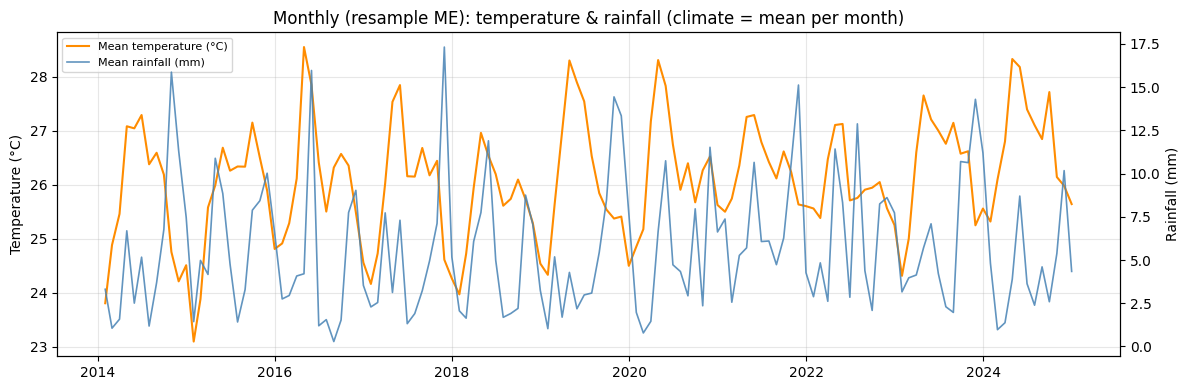

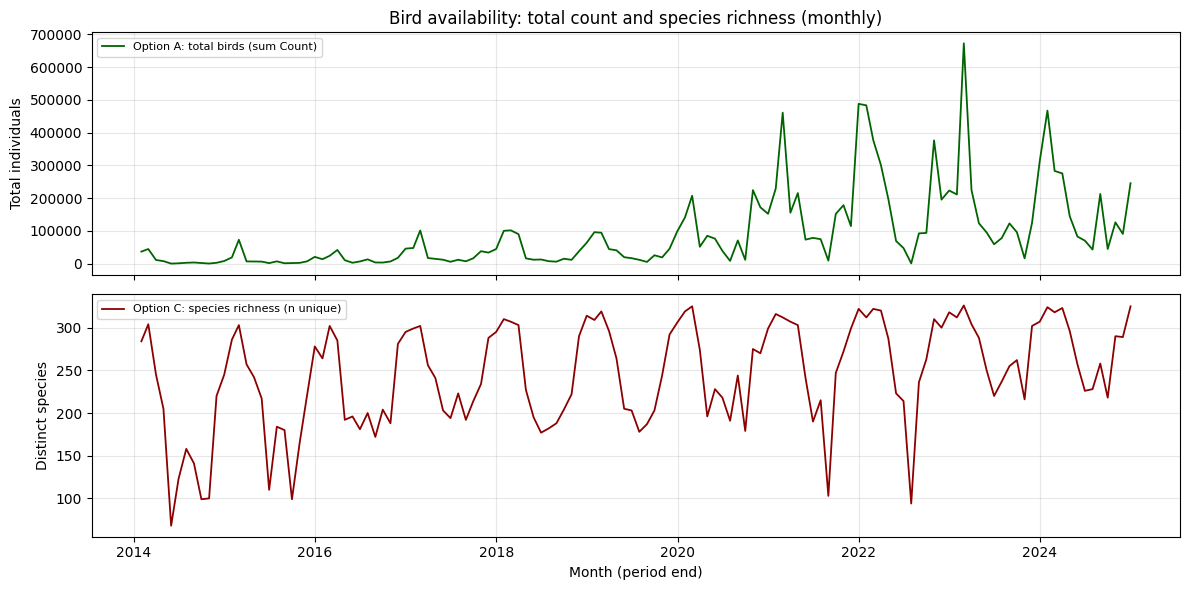

In [31]:
# Overall trends: climate + Option A (total birds) + Option C (richness)
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(monthly_overall.index, monthly_overall["temp_mean"], color="darkorange", lw=1.5, label="Mean temperature (°C)")
ax1.set_ylabel("Temperature (°C)")
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(monthly_overall.index, monthly_overall["rainfall"], color="steelblue", lw=1.2, alpha=0.85, label="Mean rainfall (mm)")
ax2.set_ylabel("Rainfall (mm)")
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left", fontsize=8)
ax1.set_title("Monthly (resample ME): temperature & rainfall (climate = mean per month)")
plt.tight_layout()
plt.savefig("images/clim_fig_ts_temp_rain.png", dpi=150, bbox_inches="tight")
plt.show()

fig, (ax_a, ax_c) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax_a.plot(monthly_overall.index, monthly_overall["total_birds"], color="darkgreen", lw=1.3, label="Option A: total birds (sum Count)")
ax_a.set_ylabel("Total individuals")
ax_a.legend(loc="upper left", fontsize=8)
ax_a.grid(alpha=0.3)
ax_a.set_title("Bird availability: total count and species richness (monthly)")

ax_c.plot(monthly_overall.index, monthly_overall["species_richness"], color="darkred", lw=1.3, label="Option C: species richness (n unique)")
ax_c.set_ylabel("Distinct species")
ax_c.set_xlabel("Month (period end)")
ax_c.legend(loc="upper left", fontsize=8)
ax_c.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/clim_fig_ts_birds_availability.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 3. Seasonal patterns (month-of-year)

Aggregate **(year × calendar month)** from row-level `work`, then average across years for a typical-year profile (same idea as before). Standardize each series across months 1–12 for shape comparison.


In [ ]:
work["year"] = work["Date"].dt.year
work["cal_month"] = work["Date"].dt.month

ym = (
    work.groupby(["year", "cal_month"], as_index=False)
    .agg(
        total_birds=("individualCount", "sum"),
        species_richness=("verbatimScientificName", lambda s: s.dropna().nunique()),
        n_obs=("individualCount", "count"),
        **{f"{c}_mean": (c, "mean") for c in climate_cols},
    )
    .sort_values(["year", "cal_month"])
)


def se_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(len(x)))


seasonal = (
    ym.groupby("cal_month", as_index=False)
    .agg(
        total_birds_mean=("total_birds", "mean"),
        total_birds_se=("total_birds", se_mean),
        species_richness_mean=("species_richness", "mean"),
        species_richness_se=("species_richness", se_mean),
        temp_mean_mean=("temp_mean_mean", "mean"),
        temp_mean_se=("temp_mean_mean", se_mean),
        rainfall_mean=("rainfall_mean", "mean"),
        rainfall_se=("rainfall_mean", se_mean),
        humid_mean_mean=("humid_mean_mean", "mean"),
        humid_mean_se=("humid_mean_mean", se_mean),
        wind_mean_mean=("wind_mean_mean", "mean"),
        wind_mean_se=("wind_mean_mean", se_mean),
        shortwave_radiation_mean=("shortwave_radiation_mean", "mean"),
        shortwave_radiation_se=("shortwave_radiation_mean", se_mean),
    )
    .sort_values("cal_month")
)

months = seasonal["cal_month"].values
x = np.arange(1, 13)


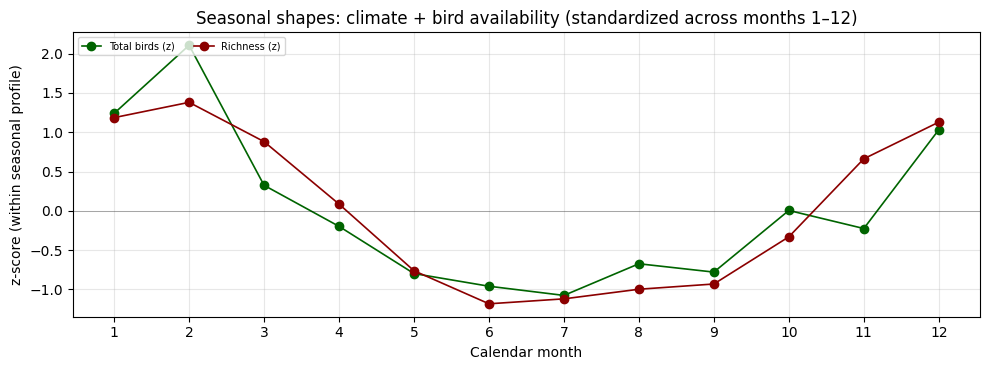

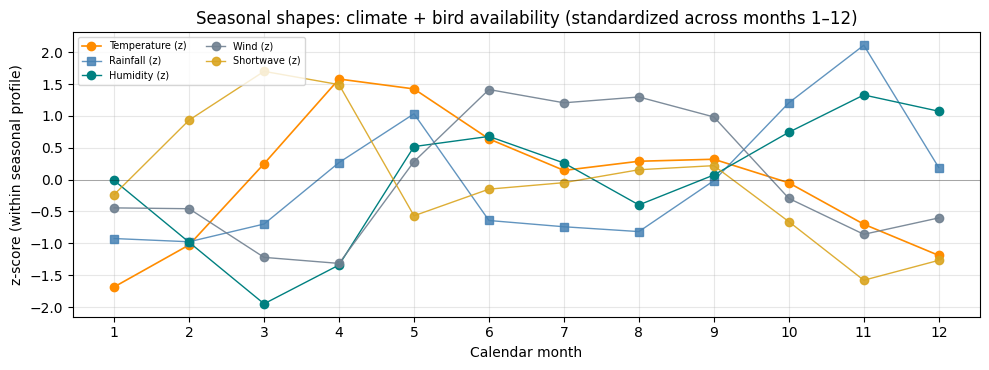

In [32]:
def z12(s):
    s = np.asarray(s, dtype=float)
    m, sd = np.nanmean(s), np.nanstd(s, ddof=1)
    if not np.isfinite(sd) or sd == 0:
        return np.zeros_like(s, dtype=float)
    return (s - m) / sd


fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(months, z12(seasonal["total_birds_mean"]), "-o", color="darkgreen", lw=1.2, label="Total birds (z)")
ax.plot(months, z12(seasonal["species_richness_mean"]), "-o", color="darkred", lw=1.2, label="Richness (z)")
ax.axhline(0, color="black", lw=0.5, alpha=0.4)
ax.set_xticks(x)
ax.set_xlabel("Calendar month")
ax.set_ylabel("z-score (within seasonal profile)")
ax.legend(loc="upper left", ncol=2, fontsize=7)
ax.set_title("Seasonal shapes: climate + bird availability (standardized across months 1–12)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/clim_fig_seasonal_z_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(months, z12(seasonal["temp_mean_mean"]), "-o", color="darkorange", lw=1.2, label="Temperature (z)")
ax.plot(months, z12(seasonal["rainfall_mean"]), "-s", color="steelblue", lw=1.0, alpha=0.85, label="Rainfall (z)")
ax.plot(months, z12(seasonal["humid_mean_mean"]), "-o", color="teal", lw=1.0, label="Humidity (z)")
ax.plot(months, z12(seasonal["wind_mean_mean"]), "-o", color="slategray", lw=1.0, alpha=0.9, label="Wind (z)")
ax.plot(months, z12(seasonal["shortwave_radiation_mean"]), "-o", color="goldenrod", lw=1.0, alpha=0.9, label="Shortwave (z)")
ax.axhline(0, color="black", lw=0.5, alpha=0.4)
ax.set_xticks(x)
ax.set_xlabel("Calendar month")
ax.set_ylabel("z-score (within seasonal profile)")
ax.legend(loc="upper left", ncol=2, fontsize=7)
ax.set_title("Seasonal shapes: climate + bird availability (standardized across months 1–12)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/clim_fig_seasonal_z_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
